<a href="https://colab.research.google.com/github/mailech/SmartEnergy-Consumption/blob/Avany-Manoj/h.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')


    df = pd.DataFrame(date_rng, columns=['timestamp'])


    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])


    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)


    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)

    # Other appliances
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])

    # Total power
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    # Create parent directories if they don't exist
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")

if __name__ == "__main__":
    generate_data()


Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv


/tmp/ipython-input-2244698090.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Weekly energy in kWh
weekly_energy = df['total_power'].resample('W').sum() / 1000  # convert Wh to kWh

print(weekly_energy)


timestamp
2023-01-01      9.824
2023-01-08     70.431
2023-01-15     71.177
2023-01-22     65.922
2023-01-29     58.448
2023-02-05     60.695
2023-02-12     76.772
2023-02-19     76.890
2023-02-26     60.515
2023-03-05     58.649
2023-03-12     83.159
2023-03-19     53.240
2023-03-26     58.023
2023-04-02    119.859
2023-04-09    260.872
2023-04-16    264.415
2023-04-23    269.897
2023-04-30    279.494
2023-05-07    279.748
2023-05-14    295.037
2023-05-21    254.332
2023-05-28    248.098
2023-06-04    277.501
2023-06-11    268.805
2023-06-18    280.070
2023-06-25    265.841
2023-07-02    143.234
Freq: W-SUN, Name: total_power, dtype: float64


In [ ]:
weekly_appliance = df.resample('W').sum() / 1000
print(weekly_appliance)


            fridge       ac  lights  microwave  total_power
timestamp                                                  
2023-01-01   1.581    4.649   0.832      2.762        9.824
2023-01-08  13.400   38.899   5.689     12.443       70.431
2023-01-15  15.227   26.398   5.423     24.129       71.177
2023-01-22  15.496   30.039   5.458     14.929       65.922
2023-01-29  14.881   26.782   5.038     11.747       58.448
2023-02-05  14.194   22.713   5.428     18.360       60.695
2023-02-12  13.187   32.885   5.552     25.148       76.772
2023-02-19  14.606   43.687   5.326     13.271       76.890
2023-02-26  15.017   27.093   5.342     13.063       60.515
2023-03-05  13.427   24.774   5.072     15.376       58.649
2023-03-12  16.651   41.065   5.420     20.023       83.159
2023-03-19  16.293   21.136   5.893      9.918       53.240
2023-03-26  15.133   22.814   4.866     15.210       58.023
2023-04-02  14.429   80.665   5.654     19.111      119.859
2023-04-09  13.306  226.027   5.268     

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Convert to weekly energy (kWh)
weekly = df.resample('W').sum() / 1000  # Wh → kWh


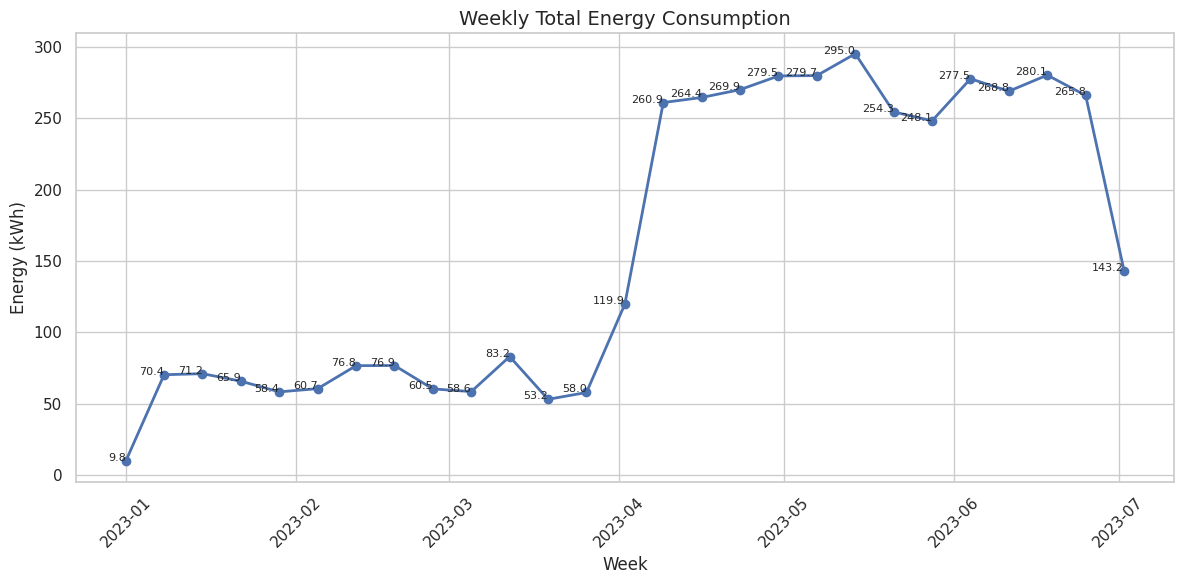

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(weekly.index, weekly['total_power'],
         marker='o', linestyle='-', linewidth=2)

plt.title("Weekly Total Energy Consumption", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Energy (kWh)", fontsize=12)

plt.grid(True)
plt.xticks(rotation=45)

# Annotate each point
for i, value in enumerate(weekly['total_power']):
    plt.text(weekly.index[i], value,
             f"{value:.1f}", fontsize=8,
             ha='right')

plt.tight_layout()
plt.show()

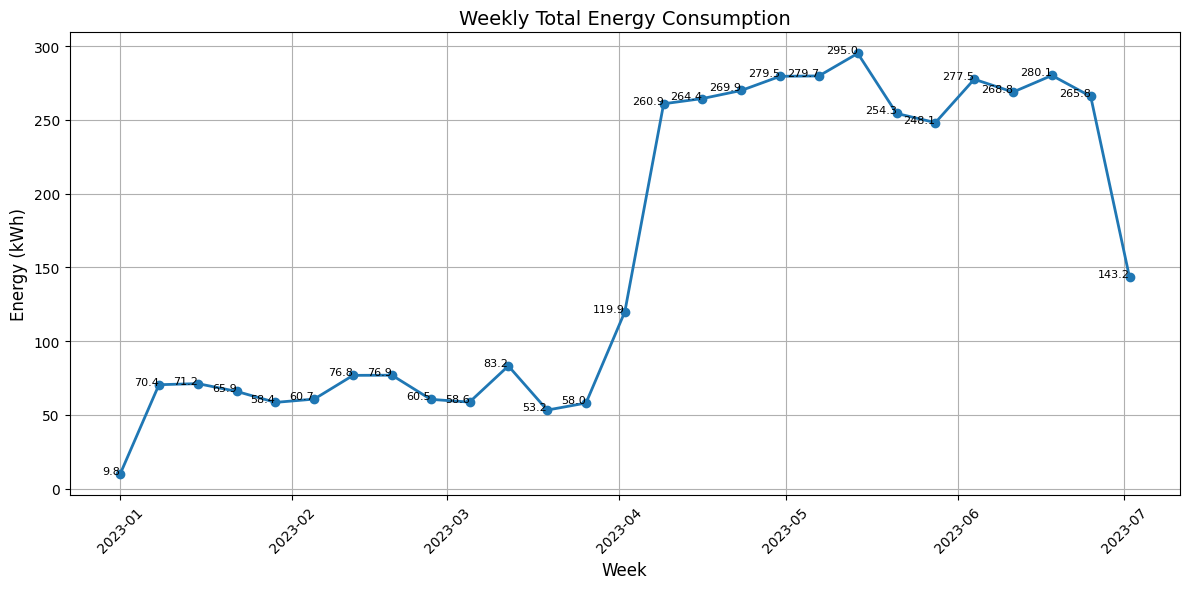

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(weekly.index, weekly['total_power'],
         marker='o', linestyle='-', linewidth=2)

plt.title("Weekly Total Energy Consumption", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Energy (kWh)", fontsize=12)

plt.grid(True)
plt.xticks(rotation=45)

# Annotate each point
for i, value in enumerate(weekly['total_power']):
    plt.text(weekly.index[i], value,
             f"{value:.1f}", fontsize=8,
             ha='right')

plt.tight_layout()
plt.show()


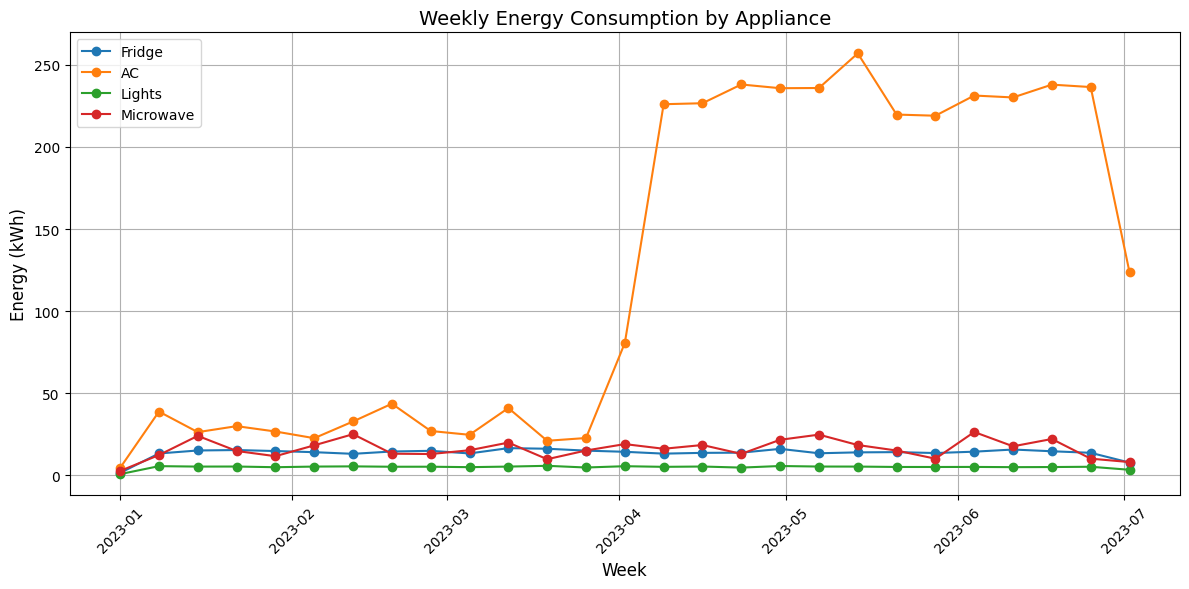

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(weekly.index, weekly['fridge'], marker='o', label='Fridge')
plt.plot(weekly.index, weekly['ac'], marker='o', label='AC')
plt.plot(weekly.index, weekly['lights'], marker='o', label='Lights')
plt.plot(weekly.index, weekly['microwave'], marker='o', label='Microwave')

plt.title("Weekly Energy Consumption by Appliance", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Energy (kWh)", fontsize=12)

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
sns.set(style="whitegrid")


/tmp/ipython-input-2897721226.py:51: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


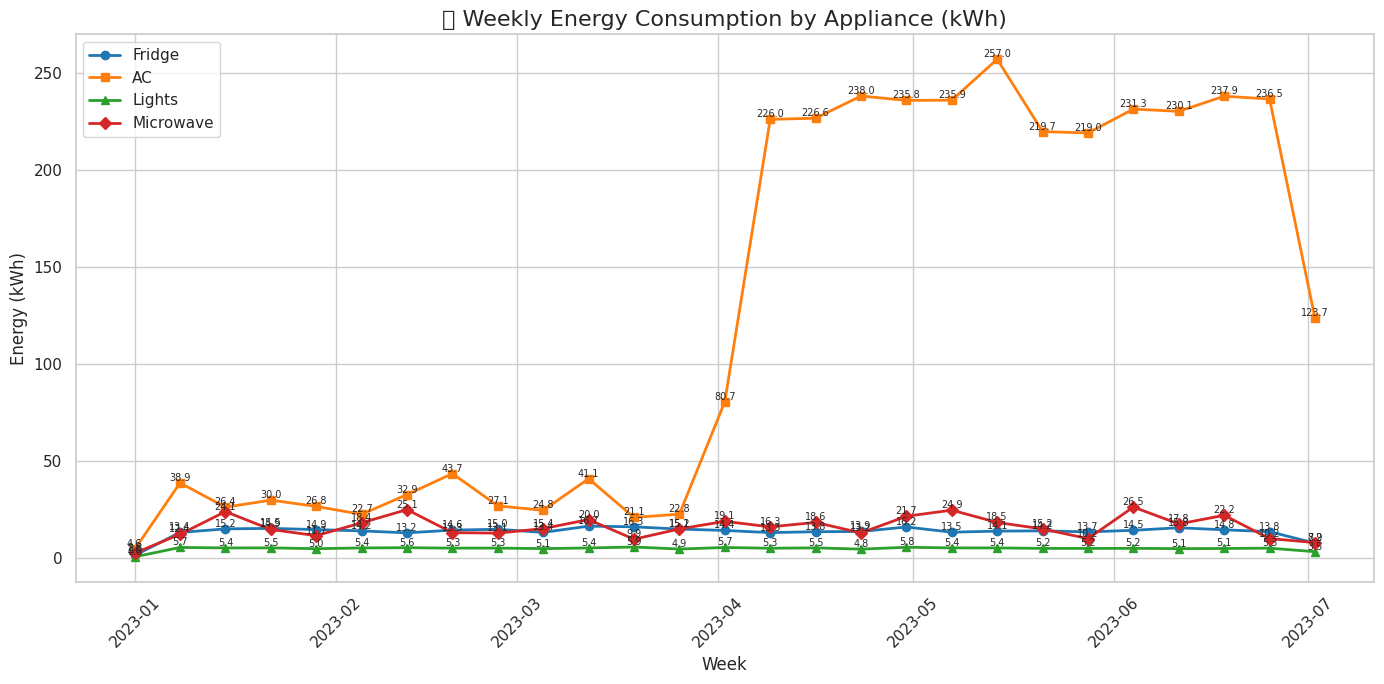

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")

df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Weekly energy (kWh)
weekly = df.resample('W').sum() / 1000

# Styling
sns.set(style="whitegrid")
plt.figure(figsize=(14,7))

# Plot each appliance with unique style
appliances = {
    "Fridge": ("fridge", "o", "#1f77b4"),
    "AC": ("ac", "s", "#ff7f0e"),
    "Lights": ("lights", "^", "#2ca02c"),
    "Microwave": ("microwave", "D", "#d62728")
}

for label, (col, marker, color) in appliances.items():
    plt.plot(
        weekly.index,
        weekly[col],
        marker=marker,
        markersize=6,
        linewidth=2,
        label=label,
        color=color
    )

    # Add value labels
    for x, y in zip(weekly.index, weekly[col]):
        plt.text(x, y, f"{y:.1f}", fontsize=7,
                 ha='center', va='bottom')

# Titles and labels
plt.title("✨ Weekly Energy Consumption by Appliance (kWh)", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Energy (kWh)", fontsize=12)

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
available_cols = ['fridge', 'microwave']
df['total_kitchen_power'] = df[available_cols].sum(axis=1)
df['High_Usage'] = df['total_kitchen_power'] > 1.0

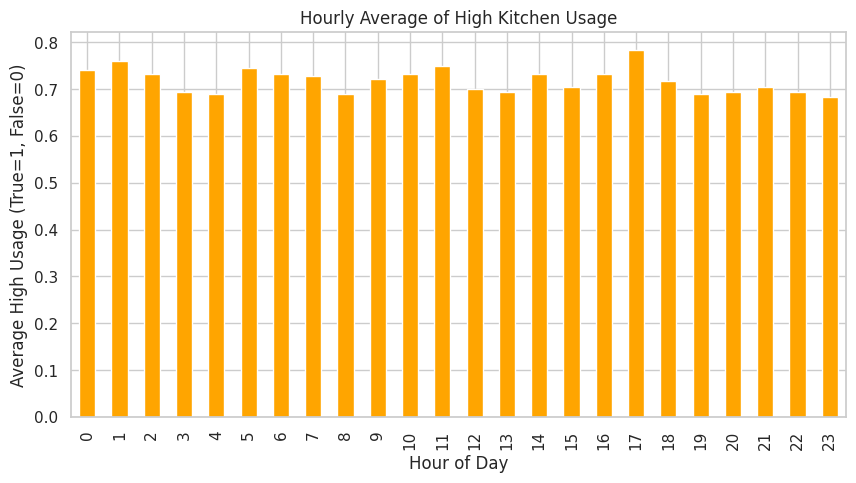

In [ ]:
df['hour']=df.index.hour
hourly_status=df.groupby('hour')['High_Usage'].mean()
plt.figure(figsize=(10,5))
hourly_status.plot(kind='bar',color='orange')
plt.title('Hourly Average of High Kitchen Usage')
plt.xlabel('Hour of Day')
plt.ylabel('Average High Usage (True=1, False=0)')
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
print("Imported seasonal_decompose and matplotlib.pyplot as plt.")

Imported seasonal_decompose and matplotlib.pyplot as plt.


In [ ]:
decomposition = seasonal_decompose(weekly['total_power'], model='additive', period=4)
print("Time series decomposition performed.")

Time series decomposition performed.


In [ ]:
import pandas as pd


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")


df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
weekly = df.resample('W').sum() / 1000

decomposition = seasonal_decompose(weekly['total_power'], model='additive', period=4)
print("Time series decomposition performed.")

Time series decomposition performed.


In [ ]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.seasonal import seasonal_decompose

def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")


generate_data()


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")


df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)


weekly = df.resample('W').sum() / 1000  # Wh → kWh

decomposition = seasonal_decompose(weekly['total_power'], model='additive', period=4)
print("Time series decomposition performed.")

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv


/tmp/ipython-input-3181352677.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='1/1/2023', end='6/30/2023', freq='H')


Time series decomposition performed.


In [ ]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.seasonal import seasonal_decompose

def generate_data():
    print("Generating synthetic energy data...")

    # Extend the date range to cover more than two years for decomposition
    date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='H')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")


generate_data()


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")


df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)


weekly = df.resample('W').sum() / 1000

decomposition = seasonal_decompose(weekly['total_power'], model='additive', period=52) # Assuming weekly data and a yearly seasonality (52 weeks)
print("Time series decomposition performed.")

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv


/tmp/ipython-input-1268763138.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='H')


Time series decomposition performed.


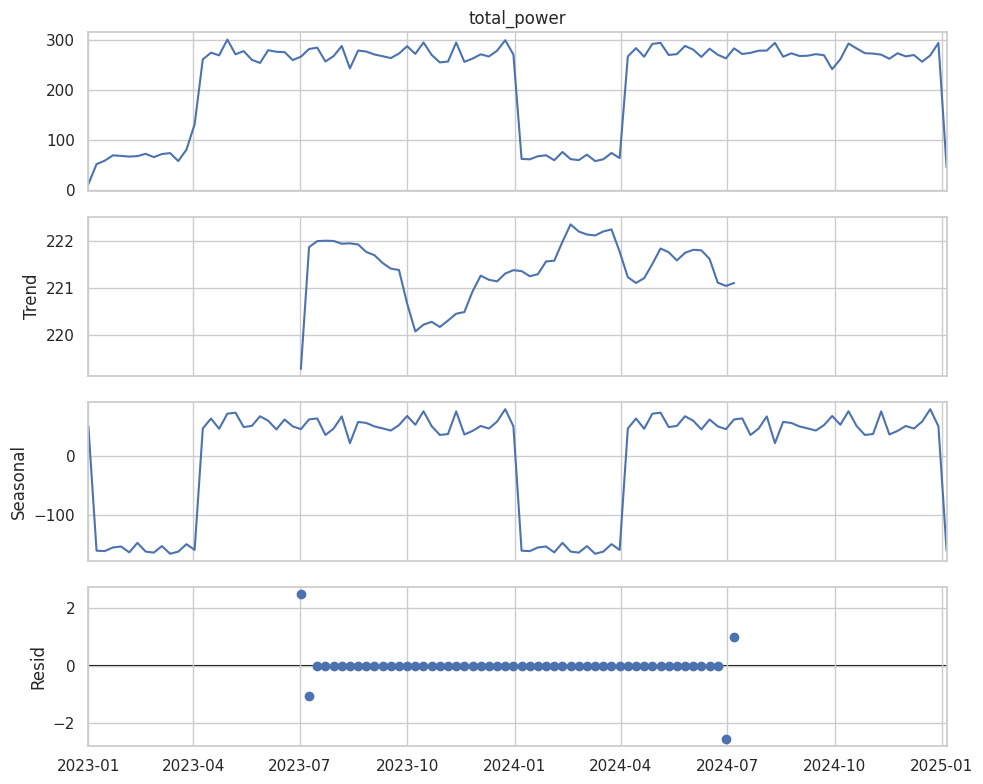

Decomposition components plotted.


In [ ]:
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()
print("Decomposition components plotted.")

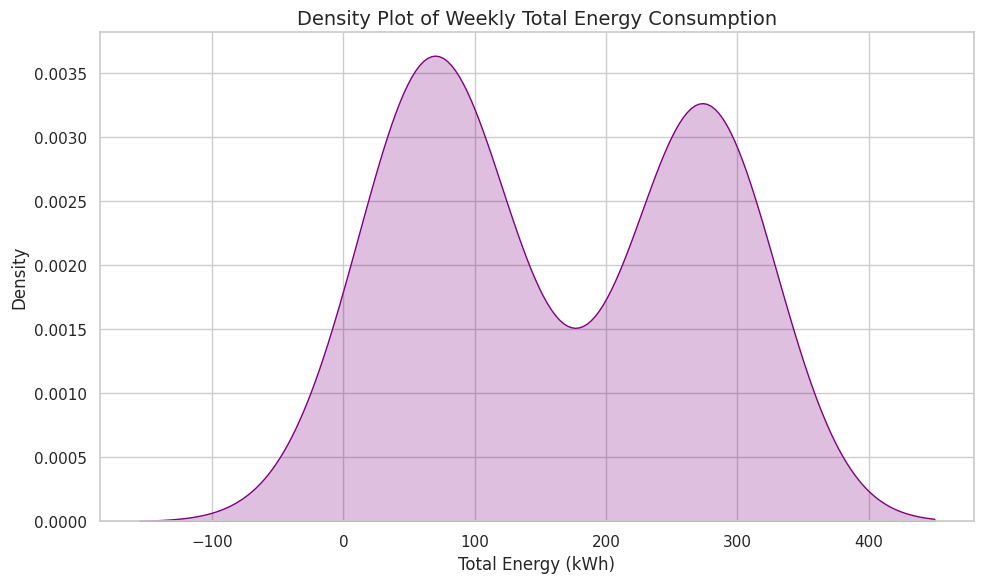

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(weekly['total_power'], fill=True, color='purple')
plt.title('Density Plot of Weekly Total Energy Consumption', fontsize=14)
plt.xlabel('Total Energy (kWh)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

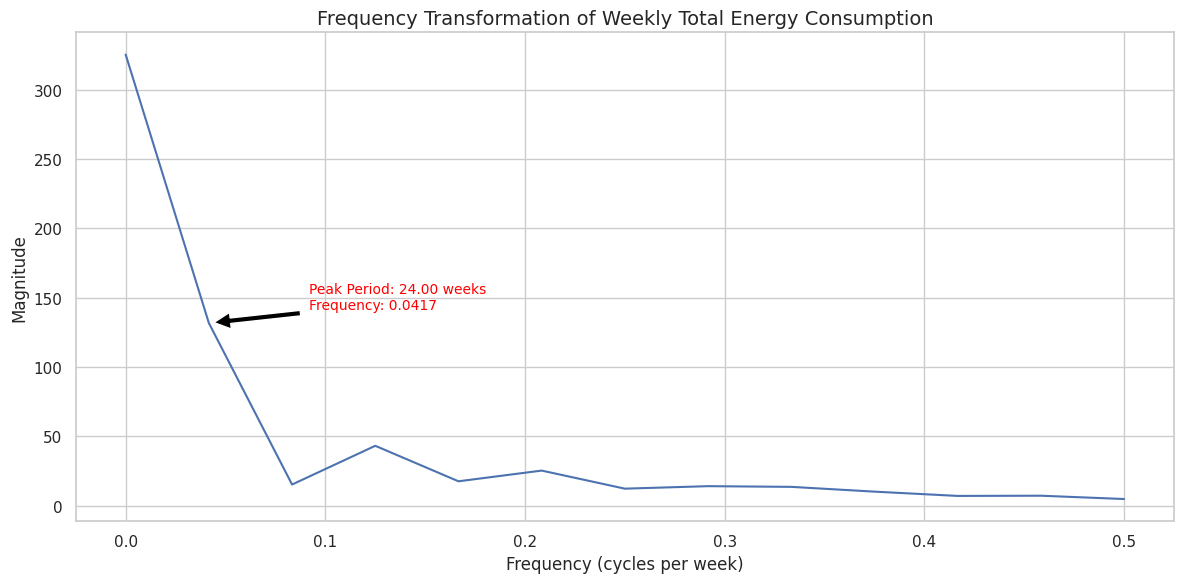

Frequency transformation plot generated with peak annotation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data = weekly['total_power'].values

N = len(data)
T = 1.0
x = np.linspace(0.0, N*T, N, endpoint=False)
yf = np.fft.fft(data)
xm = np.linspace(0.0, 1.0/(2.0*T), N//2)

plt.figure(figsize=(12, 6))
plt.plot(xm, 2.0/N * np.abs(yf[0:N//2]))
plt.title('Frequency Transformation of Weekly Total Energy Consumption', fontsize=14)
plt.xlabel('Frequency (cycles per week)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.grid(True)
peak_magnitude_idx = np.where(xm == peak_frequency)[0][0]
peak_magnitude = 2.0/N * np.abs(yf[peak_magnitude_idx])

plt.annotate(f'Peak Period: {peak_period:.2f} weeks\nFrequency: {peak_frequency:.4f}',
             xy=(peak_frequency, peak_magnitude),
             xytext=(peak_frequency + 0.05, peak_magnitude + 10),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10,
             color='red')

plt.tight_layout()
plt.show()
print("Frequency transformation plot generated with peak annotation.")

In [ ]:
import numpy as np


magnitudes = 2.0/N * np.abs(yf[1:N//2])
frequencies = xm[1:N//2]
if len(magnitudes) > 0:
    peak_idx = np.argmax(magnitudes)
    peak_frequency = frequencies[peak_idx]
    peak_period = 1.0 / peak_frequency if peak_frequency != 0 else np.inf

    print(f"The peak frequency (excluding DC) is: {peak_frequency:.4f} cycles per week")
    print(f"The corresponding peak period is: {peak_period:.2f} weeks")
else:
    print("Not enough data to determine a meaningful peak frequency and period.")

The peak frequency (excluding DC) is: 0.0417 cycles per week
The corresponding peak period is: 24.00 weeks


In [ ]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller

def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='H')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")


generate_data()


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

def adf_test(series):
    result = adfuller(series, autolag='AIC')

    print("Augmented Dickey-Fuller Test Results")
    print("-------------------------------------")
    print(f"ADF Statistic : {result[0]}")
    print(f"p-value       : {result[1]}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print("Critical Values:")

    for key, value in result[4].items():
        print(f"   {key} : {value}")

    if result[1] <= 0.05:
        print("\nConclusion: Reject the null hypothesis (Series is stationary)")
    else:
        print("\nConclusion: Fail to reject the null hypothesis (Series is non-stationary)")


print("Testing total_power column:\n")
adf_test(df['total_power'])

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv
Testing total_power column:



/tmp/ipython-input-227404973.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='H')


Augmented Dickey-Fuller Test Results
-------------------------------------
ADF Statistic : -4.881910280971728
p-value       : 3.781494903420857e-05
Lags Used     : 43
Observations  : 17477
Critical Values:
   1% : -3.430724221017473
   5% : -2.861705391222312
   10% : -2.566858033456859

Conclusion: Reject the null hypothesis (Series is stationary)


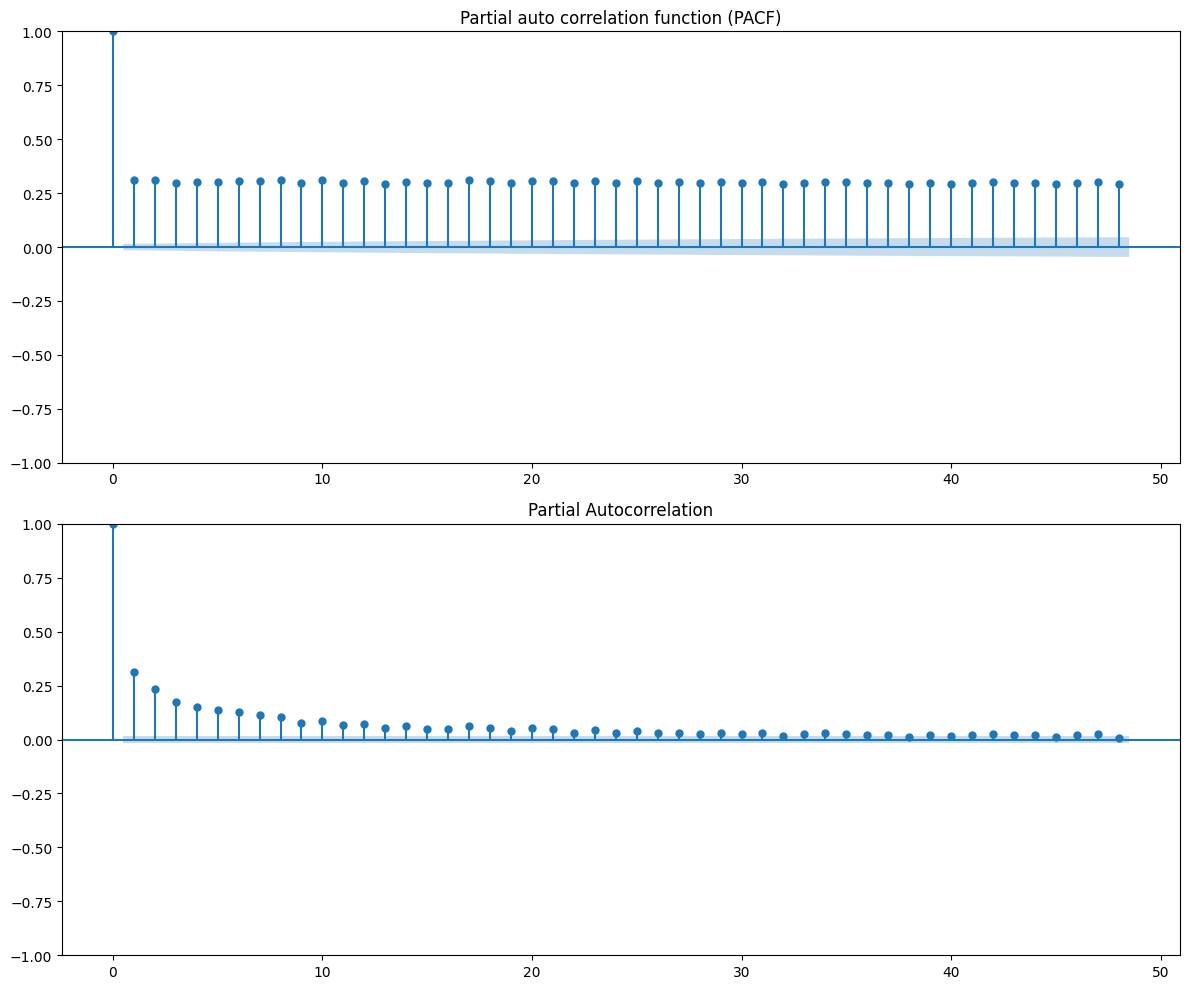

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

target_col = 'total_power'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df[target_col], lags=48, ax=ax1)
ax1.set_title("Auto correlation function (ACF)")
plot_pacf(df[target_col], lags=48, ax=ax2)
ax1.set_title("Partial auto correlation function (PACF)")
plt.tight_layout()
plt.show()

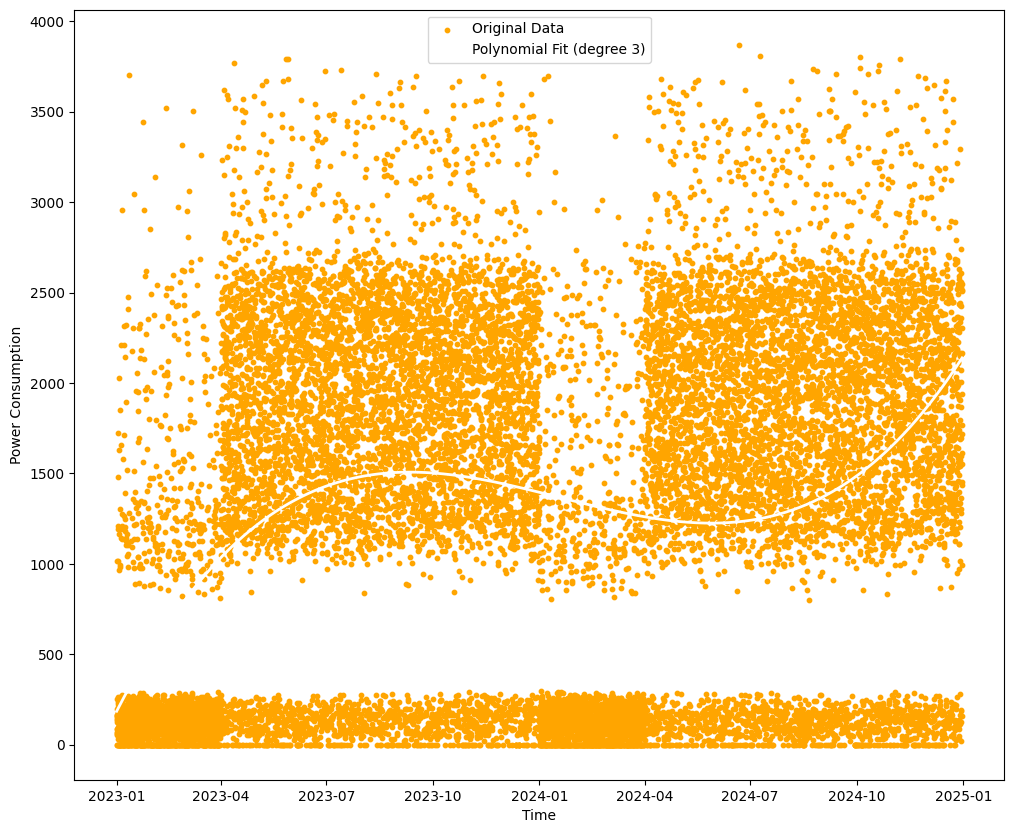

Model Coefficients: [ 0.00000000e+00  5.20598053e-01 -6.39687385e-05  2.31835084e-09]
Intercept: 185.42908662414447


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

if 'df' not in locals():
    print("Loading data...")
    df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    target_col = 'total_power'


if 'target_col' not in locals():
    target_col = 'total_power'

df['time_index'] = np.arange(len(df))
x = df[['time_index']]
y = df[target_col]

poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)
y_poly_pred = poly_model.predict(x_poly)

plt.figure(figsize=(12, 10))
plt.scatter(df.index, y, color='orange', label='Original Data', s=10)
plt.plot(df.index, y_poly_pred, color='white', linewidth=2, label='Polynomial Fit (degree 3)')
plt.xlabel('Time')
plt.ylabel('Power Consumption')

plt.legend()
plt.show()

print('Model Coefficients:', poly_model.coef_)
print('Intercept:', poly_model.intercept_)

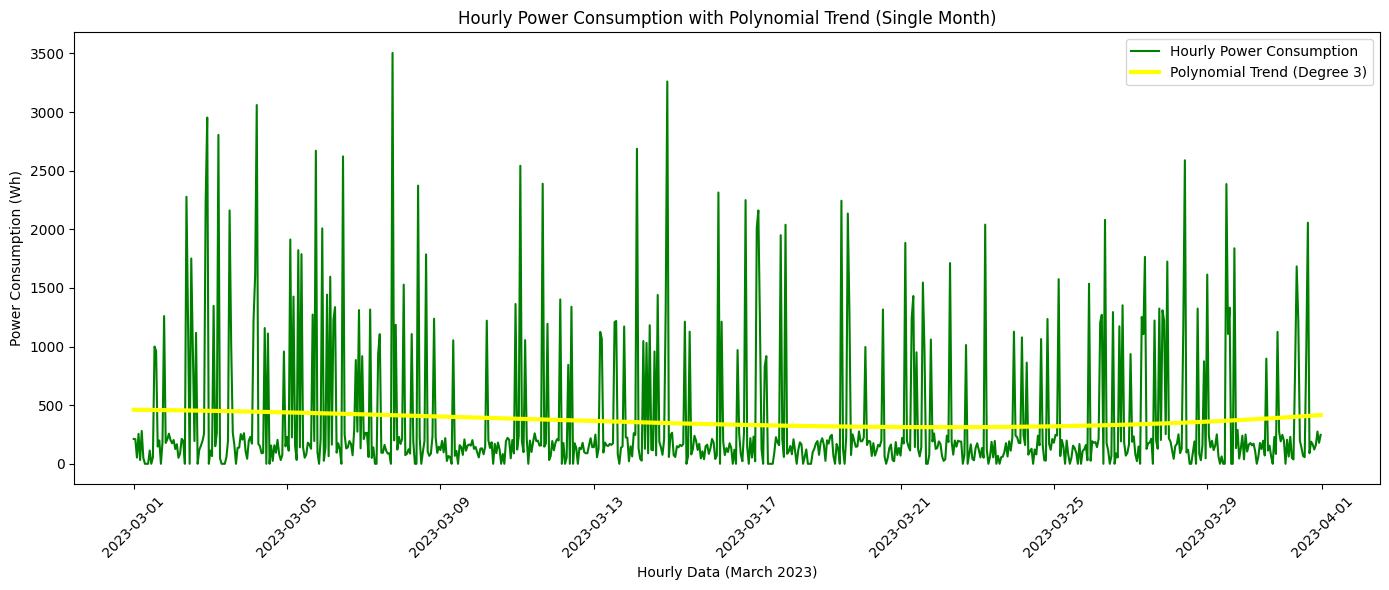

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


single_month = df.loc['2023-03']
x = np.arange(len(single_month))
y = single_month['total_power']


degree = 3
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)
y_poly = poly(x)

# Plot
plt.figure(figsize=(14,6))

plt.plot(single_month.index, y, color='green', label='Hourly Power Consumption')
plt.plot(single_month.index, y_poly, color='yellow', linewidth=3, label='Polynomial Trend (Degree 3)')

plt.xlabel("Hourly Data (March 2023)")
plt.ylabel("Power Consumption (Wh)")
plt.title("Hourly Power Consumption with Polynomial Trend (Single Month)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os


def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='h')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")
generate_data()


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df['hour_sin']=np.sin(2*np.pi*df.index.hour/24)

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv


In [ ]:
df['hour_cos']=np.cos(2*np.pi*df.index.hour/24)

In [ ]:
df['month_sin']=np.sin(2*np.pi*df.index.month/12)


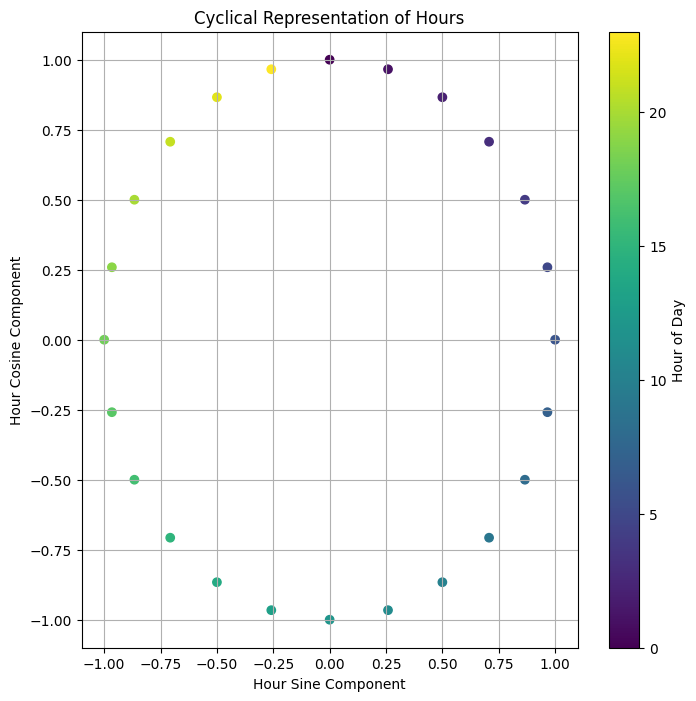

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df['month_sin']=np.sin(2*np.pi*df.index.month/12)
plt.figure(figsize=(8,8))


hours_for_plot = np.arange(24)
hour_sin_for_plot = np.sin(2 * np.pi * hours_for_plot / 24)
hour_cos_for_plot = np.cos(2 * np.pi * hours_for_plot / 24)

plt.scatter(hour_sin_for_plot, hour_cos_for_plot, c=hours_for_plot, cmap='viridis')
plt.title("Cyclical Representation of Hours")
plt.xlabel('Hour Sine Component')
plt.ylabel('Hour Cosine Component')
plt.colorbar(label='Hour of Day')
plt.grid(True)
plt.show()

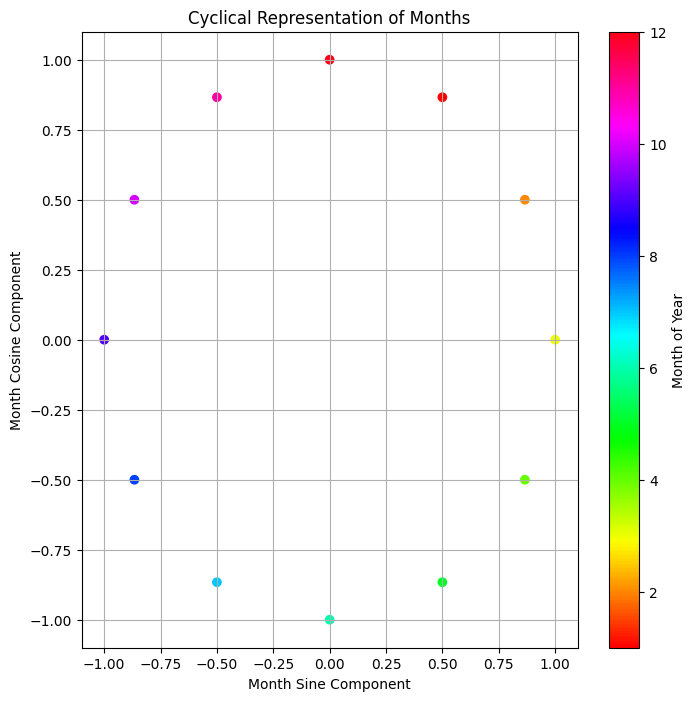

In [ ]:
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

plt.figure(figsize=(8,8))


months_for_plot = np.arange(1, 13)
month_sin_for_plot = np.sin(2 * np.pi * months_for_plot / 12)
month_cos_for_plot = np.cos(2 * np.pi * months_for_plot / 12)

plt.scatter(month_sin_for_plot, month_cos_for_plot, c=months_for_plot, cmap='hsv')
plt.title("Cyclical Representation of Months")
plt.xlabel('Month Sine Component')
plt.ylabel('Month Cosine Component')
plt.colorbar(label='Month of Year')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from numpy.fft import fft, fftfreq


target_col = 'total_power'

y = df[target_col].values
n = len(y)
t = 1.0 / 24.0

yf = fft(y)
xf = fftfreq(n, t)


xf_pos
yf_pos

print("FFT performed for hourly data. xf_pos and yf_pos are available.")

FFT performed for hourly data. xf_pos and yf_pos are available.


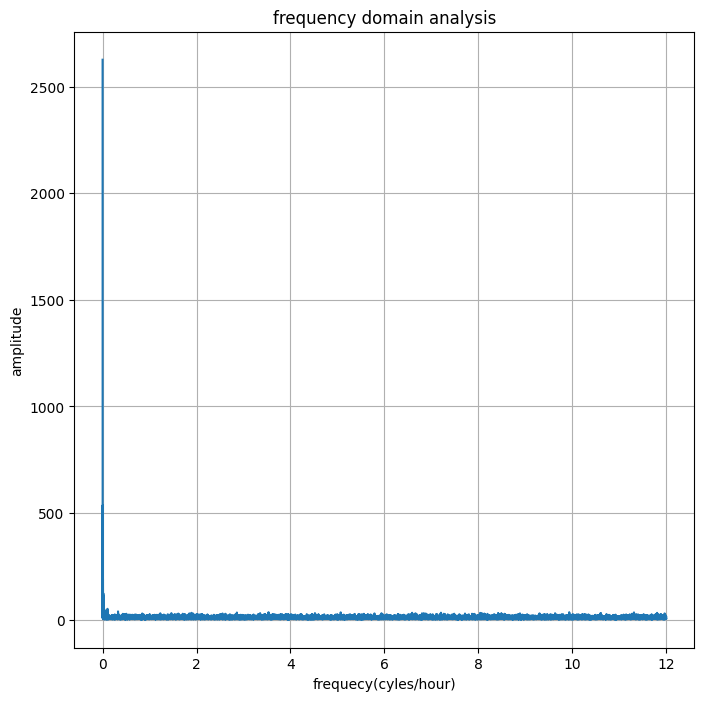

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(xf_pos,yf_pos)
plt.title("frequency domain analysis")
plt.xlabel("frequecy(cyles/hour)")
plt.ylabel("amplitude")
plt.grid(True)

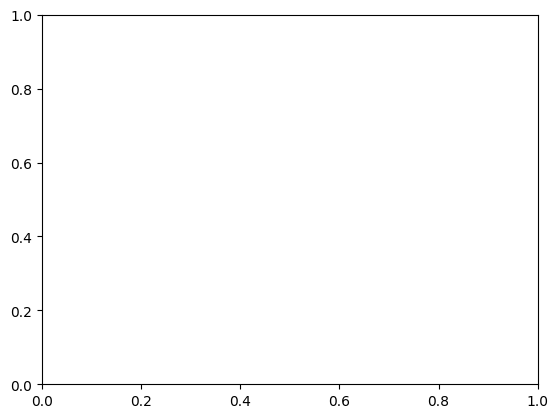

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



peak_idx = np.argmax(yf_pos[1:]) + 1
peak_freq = xf_pos[peak_idx]
period = 1 / peak_freq

plt.annotate(f"Peak Period: {period:.2f} hours",
             xy=(peak_freq, yf_pos[peak_idx]),
             xytext=(peak_freq + 0.05, yf_pos[peak_idx] + 10),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='h')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")
generate_data()


df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

df['rolling_mean'] = df['total_power'].rolling(window=24).mean()
df['rolling_std'] = df['total_power'].rolling(window=24).std()
print("Rolling mean and standard deviation calculated.")
print(df[['total_power', 'rolling_mean', 'rolling_std']].head())

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv
Rolling mean and standard deviation calculated.
                     total_power  rolling_mean  rolling_std
timestamp                                                  
2023-01-01 00:00:00           56           NaN          NaN
2023-01-01 01:00:00          217           NaN          NaN
2023-01-01 02:00:00           61           NaN          NaN
2023-01-01 03:00:00          169           NaN          NaN
2023-01-01 04:00:00          168           NaN          NaN


In [ ]:
df['z_score'] = (df['total_power'] - df['rolling_mean']) / df['rolling_std']
print("Z-scores calculated and added to 'z_score' column.")
print(df[['total_power', 'rolling_mean', 'rolling_std', 'z_score']].head(30))

Z-scores calculated and added to 'z_score' column.
                     total_power  rolling_mean  rolling_std   z_score
timestamp                                                            
2023-01-01 00:00:00           59           NaN          NaN       NaN
2023-01-01 01:00:00          167           NaN          NaN       NaN
2023-01-01 02:00:00          205           NaN          NaN       NaN
2023-01-01 03:00:00          177           NaN          NaN       NaN
2023-01-01 04:00:00           65           NaN          NaN       NaN
2023-01-01 05:00:00          184           NaN          NaN       NaN
2023-01-01 06:00:00           87           NaN          NaN       NaN
2023-01-01 07:00:00           72           NaN          NaN       NaN
2023-01-01 08:00:00          186           NaN          NaN       NaN
2023-01-01 09:00:00         1575           NaN          NaN       NaN
2023-01-01 10:00:00          180           NaN          NaN       NaN
2023-01-01 11:00:00         1097       

In [ ]:
threshold = 3
df['is_anomaly'] = np.abs(df['z_score']) > threshold
print(f"Anomalies identified based on a Z-score threshold of {threshold}.")
print(df[df['is_anomaly']].head())

Anomalies identified based on a Z-score threshold of 3.
                     fridge    ac  lights  microwave  total_power  \
timestamp                                                           
2023-01-02 19:00:00       0  2340      21          0         2361   
2023-01-03 20:00:00     120  2483      87          0         2690   
2023-01-05 22:00:00       0  2475      50          0         2525   
2023-01-06 22:00:00     149  2456      58          0         2663   
2023-01-07 01:00:00     177  2324       0          0         2501   

                     rolling_mean  rolling_std   z_score  is_anomaly  
timestamp                                                             
2023-01-02 19:00:00    282.625000   533.794034  3.893590        True  
2023-01-03 20:00:00    323.458333   638.547127  3.706135        True  
2023-01-05 22:00:00    217.125000   495.393942  4.658666        True  
2023-01-06 22:00:00    254.416667   562.566086  4.281423        True  
2023-01-07 01:00:00    309.166667 

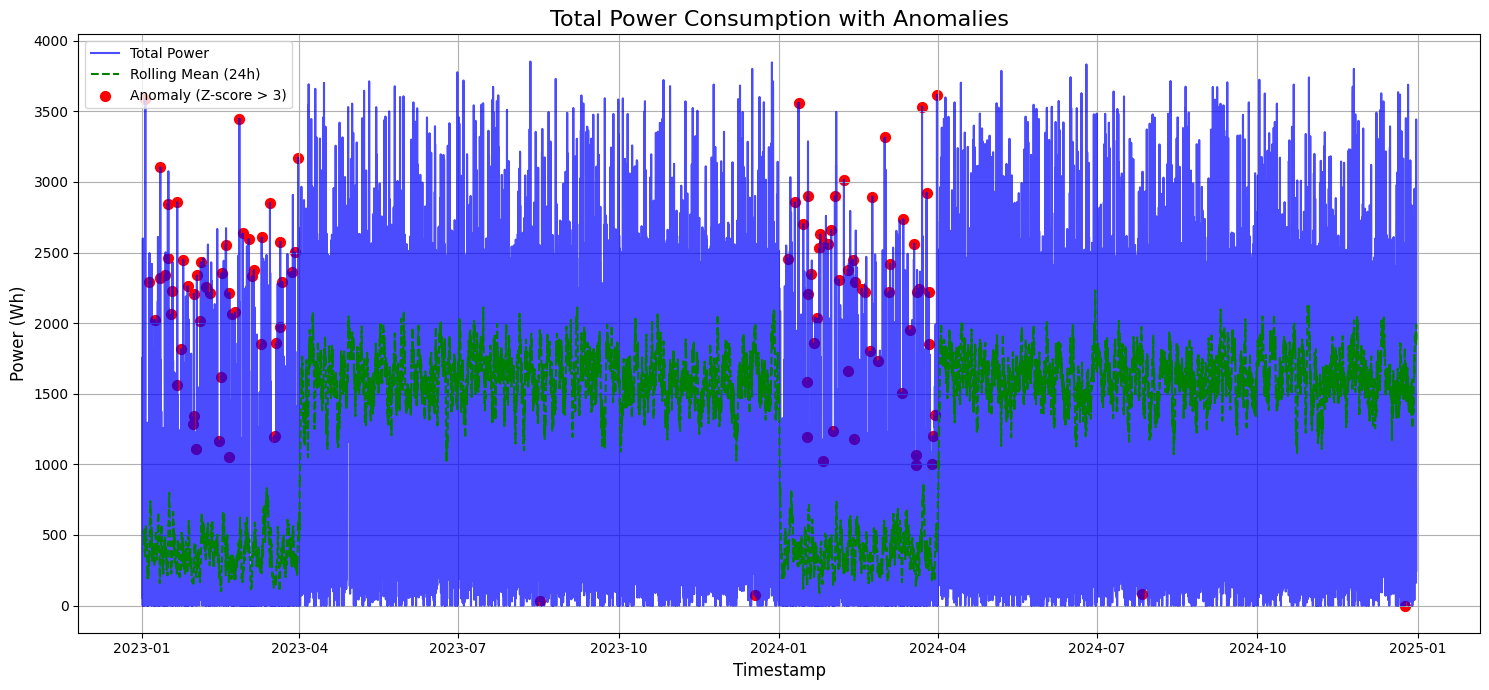

Plot of total power consumption with identified anomalies generated.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


if 'rolling_mean' not in df.columns:
    df['rolling_mean'] = df['total_power'].rolling(window=24).mean()
if 'rolling_std' not in df.columns:
    df['rolling_std'] = df['total_power'].rolling(window=24).std()


if 'z_score' not in df.columns:
    df['z_score'] = (df['total_power'] - df['rolling_mean']) / df['rolling_std']


threshold=3
if 'is_anomaly' not in df.columns:
    df['is_anomaly'] = np.abs(df['z_score']) > threshold

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['total_power'], label='Total Power', color='blue', alpha=0.7)
plt.plot(df.index, df['rolling_mean'], label='Rolling Mean (24h)', color='green', linestyle='--')
plt.scatter(df[df['is_anomaly']].index, df[df['is_anomaly']]['total_power'],
            color='red', marker='o', s=50, label=f'Anomaly (Z-score > {threshold})')

plt.title('Total Power Consumption with Anomalies', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Power (Wh)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Plot of total power consumption with identified anomalies generated.")

In [ ]:
import numpy as np
import pandas as pd

def shannon_entropy(series, bins=10):

    series = series.dropna()
    if len(series) == 0:
        return np.nan


    counts, _ = np.histogram(series, bins=bins)


    counts = counts[counts > 0]


    probabilities = counts / np.sum(counts)


    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

print("Shannon entropy function defined.")

Shannon entropy function defined.


In [ ]:
window_size = 24
df['rolling_entropy'] = df['total_power'].rolling(window=window_size).apply(shannon_entropy, raw=False)
print(f"Rolling Shannon entropy calculated with a window size of {window_size}.")
print(df[['total_power', 'rolling_entropy']].head(30))

Rolling Shannon entropy calculated with a window size of 24.
                     total_power  rolling_entropy
timestamp                                        
2023-01-01 00:00:00           56              NaN
2023-01-01 01:00:00          217              NaN
2023-01-01 02:00:00           61              NaN
2023-01-01 03:00:00          169              NaN
2023-01-01 04:00:00          168              NaN
2023-01-01 05:00:00          212              NaN
2023-01-01 06:00:00         1756              NaN
2023-01-01 07:00:00          104              NaN
2023-01-01 08:00:00            0              NaN
2023-01-01 09:00:00         1204              NaN
2023-01-01 10:00:00         2600              NaN
2023-01-01 11:00:00          161              NaN
2023-01-01 12:00:00         1738              NaN
2023-01-01 13:00:00            0              NaN
2023-01-01 14:00:00           81              NaN
2023-01-01 15:00:00         1002              NaN
2023-01-01 16:00:00            0       

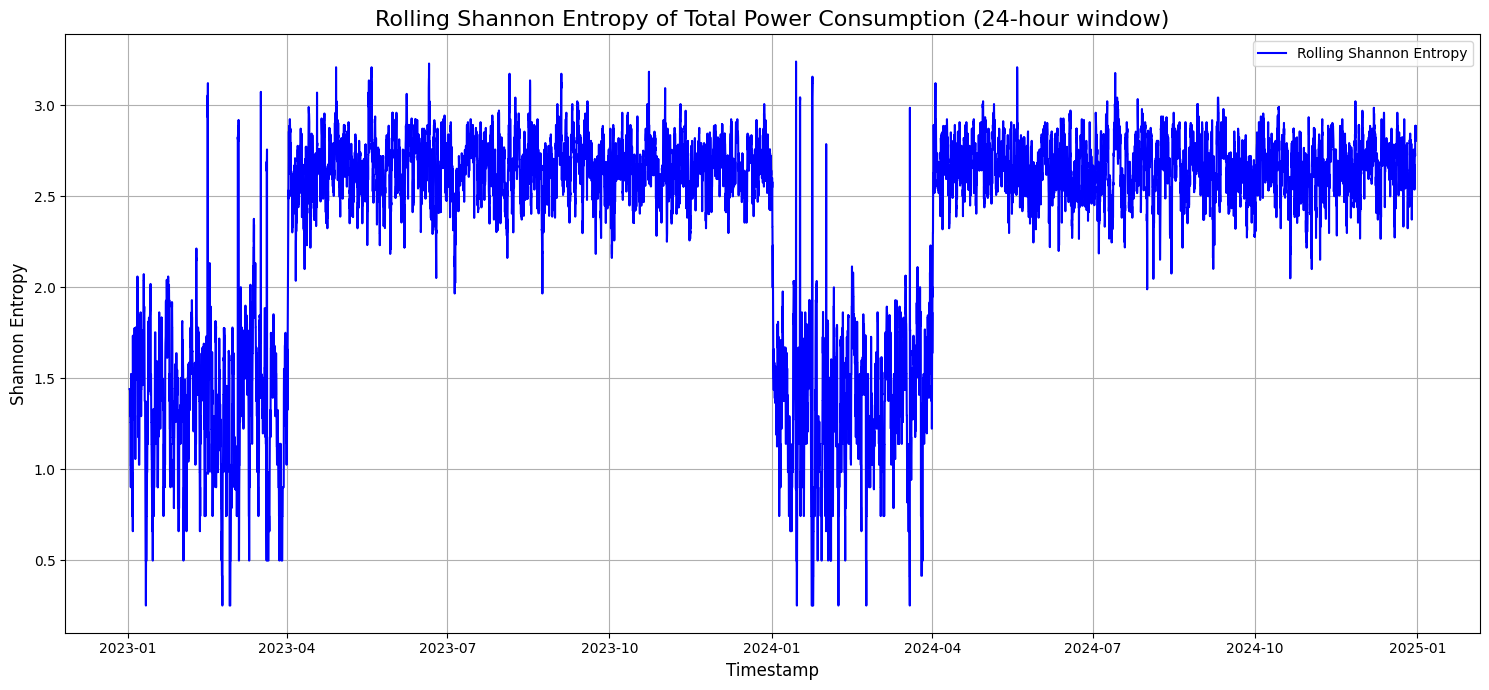

Plot of rolling Shannon entropy generated.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['rolling_entropy'], color='blue', label='Rolling Shannon Entropy')
plt.title('Rolling Shannon Entropy of Total Power Consumption (24-hour window)', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Shannon Entropy', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of rolling Shannon entropy generated.")

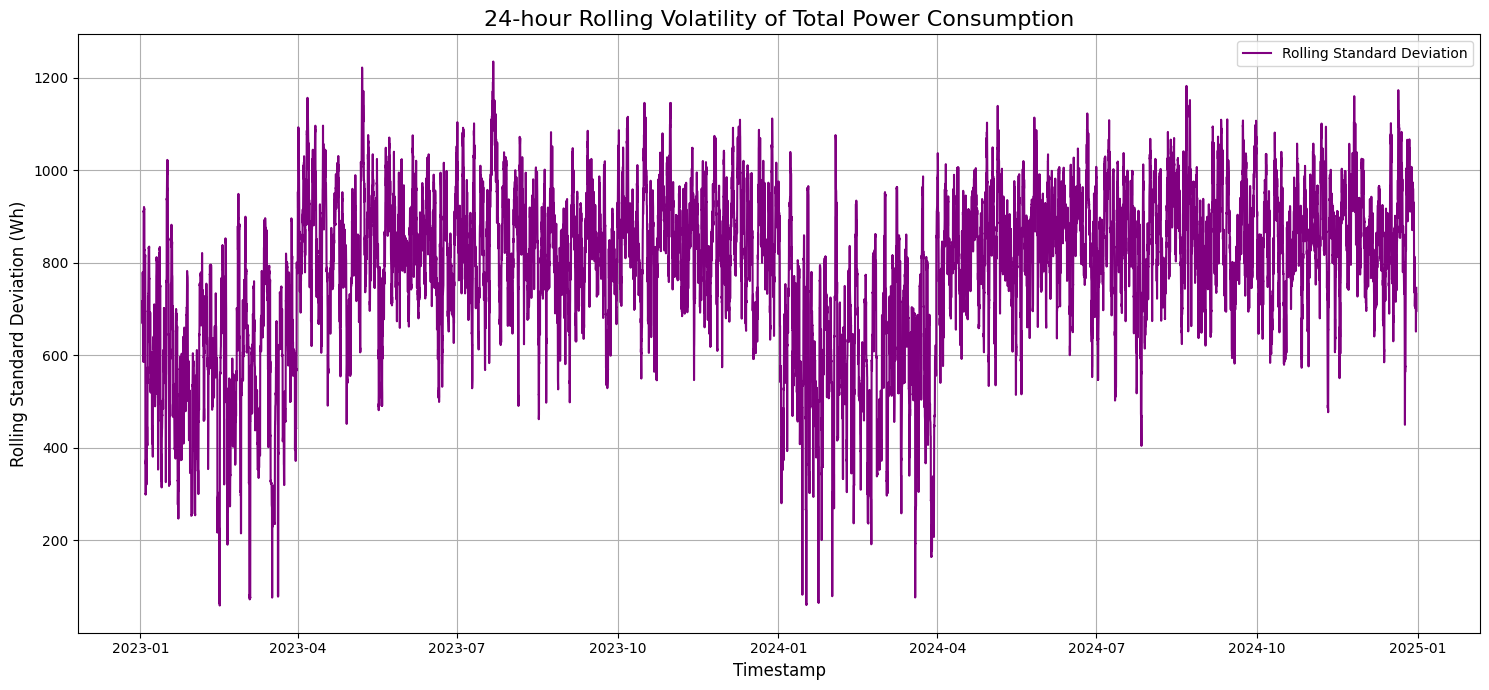

Plot of 24-hour rolling volatility generated.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['rolling_std'], color='purple', label='Rolling Standard Deviation')
plt.title('24-hour Rolling Volatility of Total Power Consumption', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Rolling Standard Deviation (Wh)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of 24-hour rolling volatility generated.")

In [ ]:
df['rolling_95th_percentile'] = df['total_power'].rolling(window=24).quantile(0.95)
print("24-hour rolling 95th percentile calculated.")
print(df[['total_power', 'rolling_95th_percentile']].head(30))

24-hour rolling 95th percentile calculated.
                     total_power  rolling_95th_percentile
timestamp                                                
2023-01-01 00:00:00           56                      NaN
2023-01-01 01:00:00          217                      NaN
2023-01-01 02:00:00           61                      NaN
2023-01-01 03:00:00          169                      NaN
2023-01-01 04:00:00          168                      NaN
2023-01-01 05:00:00          212                      NaN
2023-01-01 06:00:00         1756                      NaN
2023-01-01 07:00:00          104                      NaN
2023-01-01 08:00:00            0                      NaN
2023-01-01 09:00:00         1204                      NaN
2023-01-01 10:00:00         2600                      NaN
2023-01-01 11:00:00          161                      NaN
2023-01-01 12:00:00         1738                      NaN
2023-01-01 13:00:00            0                      NaN
2023-01-01 14:00:00         

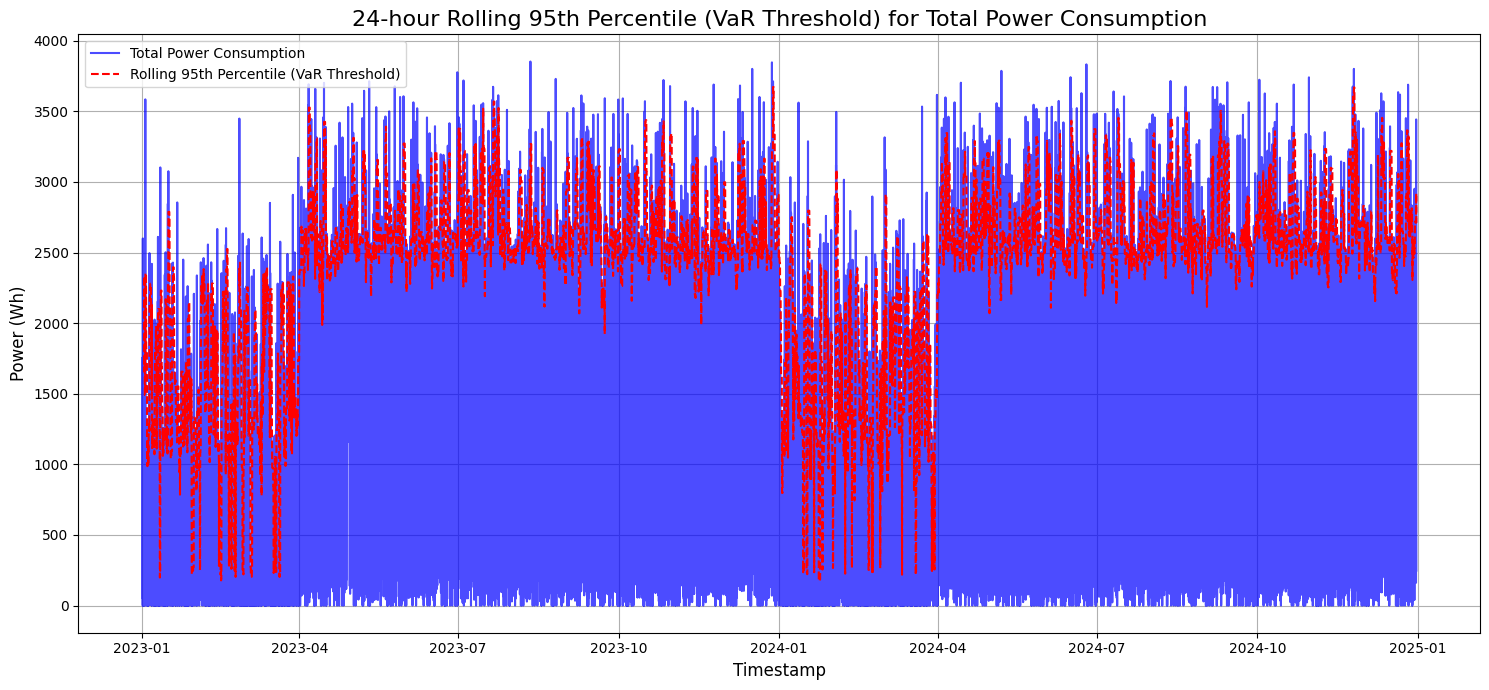

Plot of 24-hour rolling 95th percentile (VaR Threshold) generated.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df['total_power'], color='blue', alpha=0.7, label='Total Power Consumption')
plt.plot(df.index, df['rolling_95th_percentile'], color='red', linestyle='--', label='Rolling 95th Percentile (VaR Threshold)')

plt.title('24-hour Rolling 95th Percentile (VaR Threshold) for Total Power Consumption', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Power (Wh)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of 24-hour rolling 95th percentile (VaR Threshold) generated.")

In [ ]:
appliance_cols = ['fridge', 'ac', 'lights', 'microwave']
correlation_matrix = df[appliance_cols].corr()

print("Device-Level Cross-Correlation Matrix:")
print(correlation_matrix)

Device-Level Cross-Correlation Matrix:
             fridge        ac    lights  microwave
fridge     1.000000 -0.008427 -0.008695  -0.002145
ac        -0.008427  1.000000  0.000364   0.005449
lights    -0.008695  0.000364  1.000000  -0.001983
microwave -0.002145  0.005449 -0.001983   1.000000


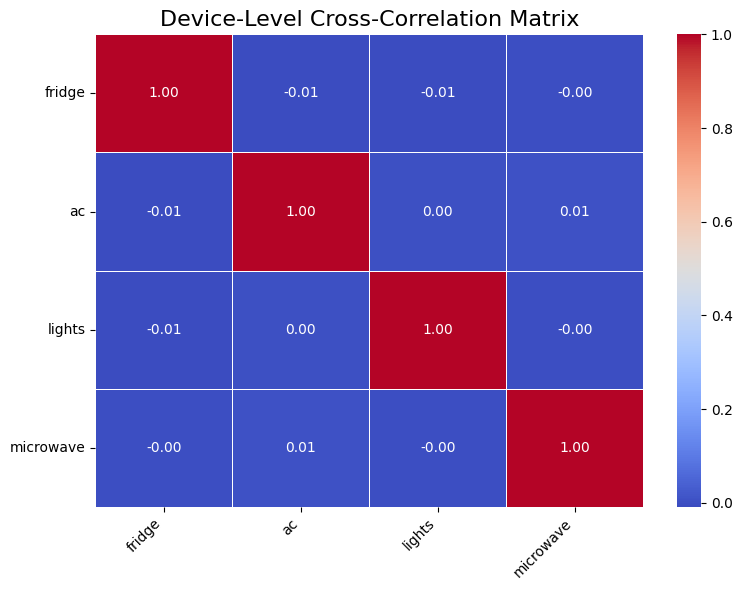

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Device-Level Cross-Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Generating synthetic energy data...
Data saved to energy_consumption_project/data/raw/energy_data.csv


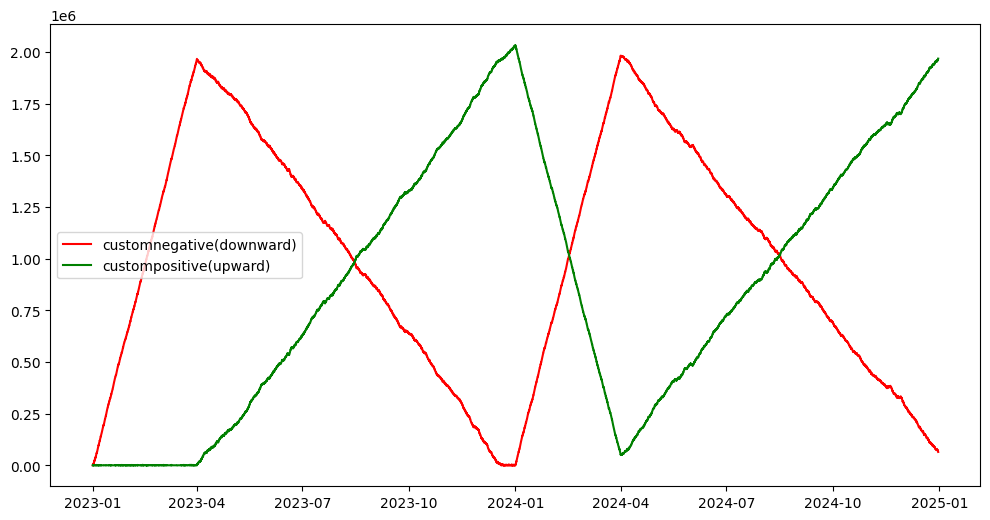

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def generate_data():
    print("Generating synthetic energy data...")

    date_rng = pd.date_range(start='1/1/2023', end='12/31/2024', freq='h')
    df = pd.DataFrame(date_rng, columns=['timestamp'])
    df['fridge'] = np.random.randint(50, 200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.3, 0.7])
    month = df['timestamp'].dt.month
    ac_prob = np.where(month >= 4, 0.8, 0.1)
    df['ac'] = np.random.randint(1000, 2500, size=(len(date_rng))) * np.random.binomial(1, ac_prob)
    hour = df['timestamp'].dt.hour
    light_prob = np.where((hour >= 18) | (hour <= 6), 0.9, 0.1)
    df['lights'] = np.random.randint(20, 100, size=(len(date_rng))) * np.random.binomial(1, light_prob)
    df['microwave'] = np.random.randint(800, 1200, size=(len(date_rng))) * np.random.choice([0, 1], size=len(date_rng), p=[0.9, 0.1])
    df['total_power'] = df['fridge'] + df['ac'] + df['lights'] + df['microwave']

    data_path = os.path.join("energy_consumption_project", "data", "raw", "energy_data.csv")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    df.to_csv(data_path, index=False)
    print(f"Data saved to {data_path}")

generate_data()


if 'df' not in locals():
    df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    target_col = 'total_power'


if 'target_col' not in locals():
    target_col = 'total_power'

def detect_cusum(x, threshold=3, drift=0):
  s_pos=np.zeros(len(x))
  s_neg=np.zeros(len(x))
  mu=np.mean(x)
  for i in range(1,len(x)):
    s_pos[i]=max(0,s_pos[i-1]+(x[i]-mu)-drift)
    s_neg[i]=max(0,s_neg[i-1]-(x[i]-mu)-drift)
  return s_pos,s_neg

s_pos,s_neg=detect_cusum(df[target_col].values, drift=0)
plt.figure(figsize=(12,6))
plt.plot(df.index,s_neg,label="customnegative(downward)",color='red')
plt.plot(df.index,s_pos,label="custompositive(upward)",color='green')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6930: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2074: RuntimeWarning: overflow encountered in divide
  place(output, cond, self._pdf(*goodargs) / scale)


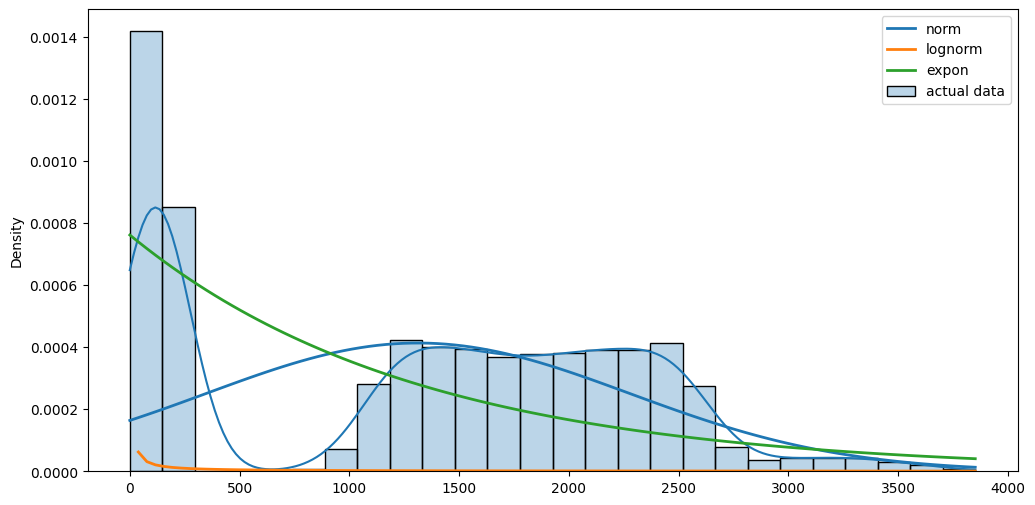

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = df[target_col].dropna().values
distributions = [stats.norm, stats.lognorm, stats.expon]
plt.figure(figsize=(12,6))
sns.histplot(data, kde=True, stat="density", alpha=0.3, label="actual data")
x = np.linspace(min(data), max(data), 100)
for dist in distributions:
  params = dist.fit(data)
  pdf = dist.pdf(x, *params)
  plt.plot(x, pdf, label=dist.name, linewidth=2)
plt.legend()
plt.show()

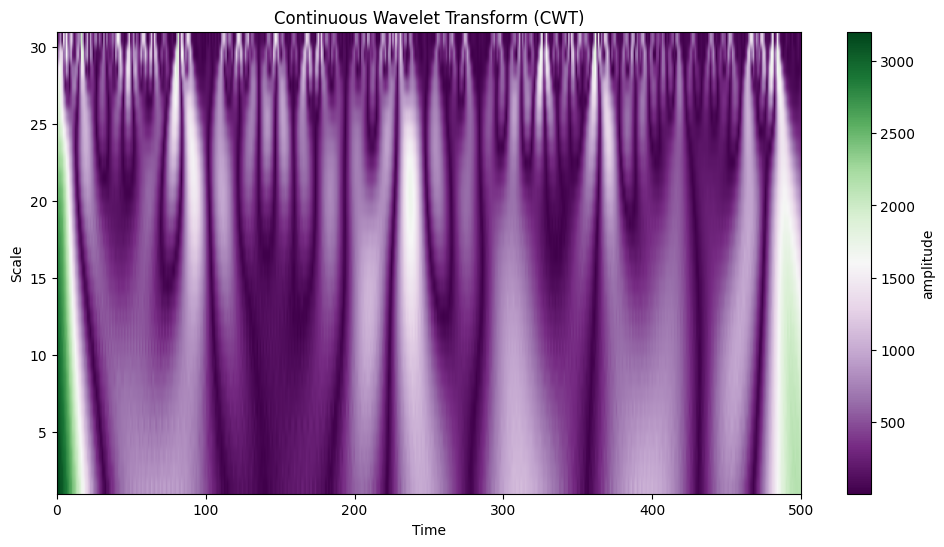

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

width=np.arange(1,31)

cwtmatr, freqs = pywt.cwt(df[target_col].values[:500], width, 'gaus1')

plt.figure(figsize=(12,6))
plt.imshow(abs(cwtmatr),extent=[0,500,1,31],cmap="PRGn",aspect='auto',vmax=abs(cwtmatr).max())
plt.colorbar(label='amplitude')
plt.title('Continuous Wavelet Transform (CWT)')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.show()

/tmp/ipython-input-657785264.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df[target_col].resample('M').sum()


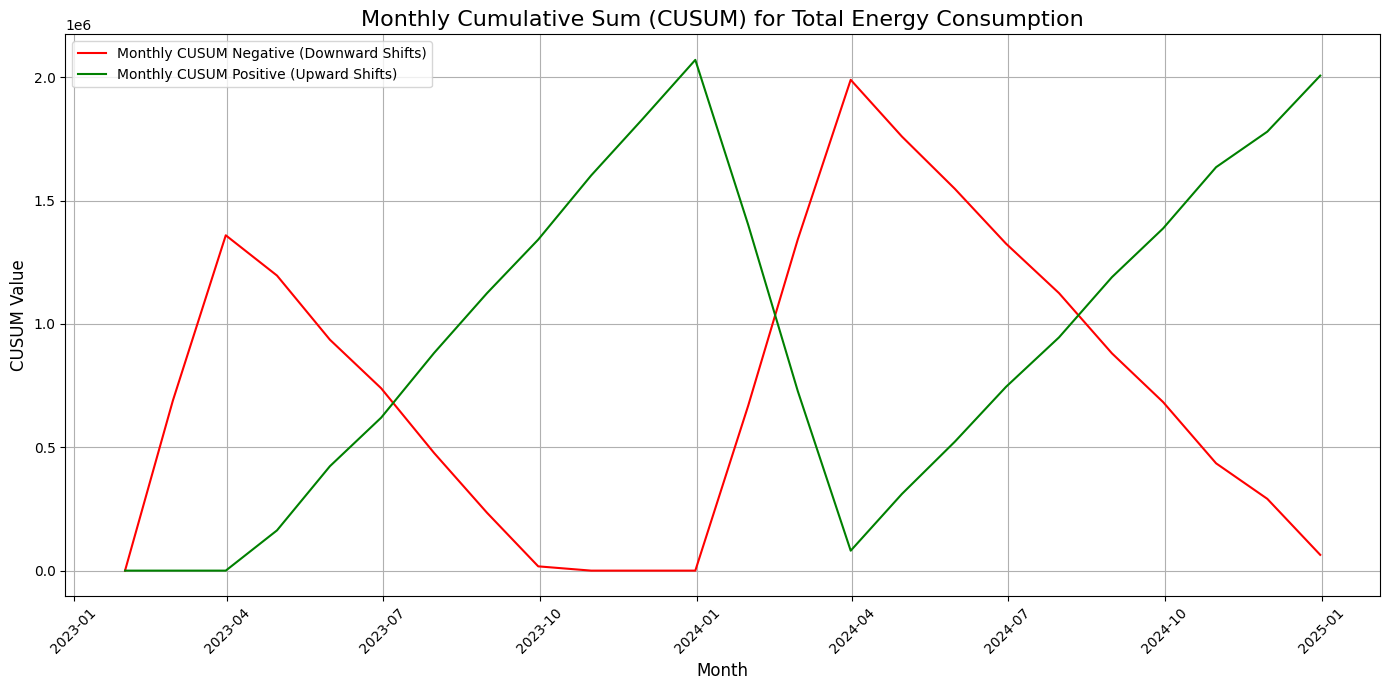

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


if 'df' not in locals():
    try:
        df = pd.read_csv("energy_consumption_project/data/raw/energy_data.csv")
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
        target_col = 'total_power'
    except FileNotFoundError:
        print("Data file not found. Please ensure data is generated.")


if 'target_col' not in locals():
    target_col = 'total_power'


monthly_data = df[target_col].resample('ME').sum()

def detect_cusum(x, threshold=3, drift=0):
  s_pos=np.zeros(len(x))
  s_neg=np.zeros(len(x))
  mu=np.mean(x)
  for i in range(1,len(x)):
    s_pos[i]=max(0,s_pos[i-1]+(x[i]-mu)-drift)
    s_neg[i]=max(0,s_neg[i-1]-(x[i]-mu)-drift)
  return s_pos,s_neg

s_pos_monthly, s_neg_monthly = detect_cusum(monthly_data.values, drift=0)


plt.figure(figsize=(14, 7))
plt.plot(monthly_data.index, s_neg_monthly, label="Monthly CUSUM Negative (Downward Shifts)", color='red')
plt.plot(monthly_data.index, s_pos_monthly, label="Monthly CUSUM Positive (Upward Shifts)", color='green')

plt.title("Monthly Cumulative Sum (CUSUM) for Total Energy Consumption", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("CUSUM Value", fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()